# Import Packages and Define Variables

In [56]:
sessionNames = ['t12.2022.04.28',  't12.2022.05.26',  't12.2022.06.21',  't12.2022.07.21',  't12.2022.08.13',
't12.2022.05.05',  't12.2022.06.02',  't12.2022.06.23',  't12.2022.07.27',  't12.2022.08.18',
't12.2022.05.17',  't12.2022.06.07',  't12.2022.06.28',  't12.2022.07.29',  't12.2022.08.23',
't12.2022.05.19',  't12.2022.06.14',  't12.2022.07.05',  't12.2022.08.02',  't12.2022.08.25',
't12.2022.05.24',  't12.2022.06.16',  't12.2022.07.14',  't12.2022.08.11']
sessionNames.sort()

In [57]:
import re 
from g2p_en import G2p
import numpy as np

g2p = G2p()
PHONE_DEF = [
    'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B',  'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K',
    'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH',
    'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH'
]
PHONE_DEF_SIL = PHONE_DEF + ['SIL']

def phoneToId(p):
    return PHONE_DEF_SIL.index(p)

# Get Datasets

In [58]:
import scipy

def loadFeaturesAndNormalize(sessionPath):
    
    dat = scipy.io.loadmat(sessionPath)

    input_features = []
    transcriptions = []
    frame_lens = []
    block_means = []
    block_stds = []
    n_trials = dat['sentenceText'].shape[0]

    #collect area 6v tx1 and spikePow features
    for i in range(n_trials):    
        #get time series of TX and spike power for this trial
        #first 128 columns = area 6v only
        features = np.concatenate([dat['tx1'][0,i][:,0:128], dat['spikePow'][0,i][:,0:128]], axis=1)

        sentence_len = features.shape[0]
        sentence = dat['sentenceText'][i].strip()

        input_features.append(features)
        transcriptions.append(sentence)
        frame_lens.append(sentence_len)

    #block-wise feature normalization
    blockNums = np.squeeze(dat['blockIdx'])
    blockList = np.unique(blockNums)
    blocks = []
    for b in range(len(blockList)):
        sentIdx = np.argwhere(blockNums==blockList[b])
        sentIdx = sentIdx[:,0].astype(np.int32)
        blocks.append(sentIdx)

    for b in range(len(blocks)):
        feats = np.concatenate(input_features[blocks[b][0]:(blocks[b][-1]+1)], axis=0)
        feats_mean = np.mean(feats, axis=0, keepdims=True)
        feats_std = np.std(feats, axis=0, keepdims=True)
        for i in blocks[b]:
            input_features[i] = (input_features[i] - feats_mean) / (feats_std + 1e-8)

    #convert to tfRecord file
    session_data = {
        'inputFeatures': input_features,
        'transcriptions': transcriptions,
        'frameLens': frame_lens
    }

    return session_data

In [59]:
import os

def getDataset(fileName):
    session_data = loadFeaturesAndNormalize(fileName)
        
    allDat = []
    trueSentences = []
    seqElements = []
    
    for x in range(len(session_data['inputFeatures'])):
        allDat.append(session_data['inputFeatures'][x])
        trueSentences.append(session_data['transcriptions'][x])
        
        thisTranscription = str(session_data['transcriptions'][x]).strip()
        thisTranscription = re.sub(r'[^a-zA-Z\- \']', '', thisTranscription)
        thisTranscription = thisTranscription.replace('--', '').lower()
        addInterWordSymbol = True

        phonemes = []
        for p in g2p(thisTranscription):
            if addInterWordSymbol and p==' ':
                phonemes.append('SIL')
            p = re.sub(r'[0-9]', '', p)  # Remove stress
            if re.match(r'[A-Z]+', p):  # Only keep phonemes
                phonemes.append(p)

        #add one SIL symbol at the end so there's one at the end of each word
        if addInterWordSymbol:
            phonemes.append('SIL')

        seqLen = len(phonemes)
        maxSeqLen = 500
        seqClassIDs = np.zeros([maxSeqLen]).astype(np.int32)
        seqClassIDs[0:seqLen] = [phoneToId(p) + 1 for p in phonemes]
        seqElements.append(seqClassIDs)

    newDataset = {}
    newDataset['sentenceDat'] = allDat
    newDataset['transcriptions'] = trueSentences
    newDataset['phonemes'] = seqElements
    
    timeSeriesLens = []
    phoneLens = []
    for x in range(len(newDataset['sentenceDat'])):
        timeSeriesLens.append(newDataset['sentenceDat'][x].shape[0])
        
        zeroIdx = np.argwhere(newDataset['phonemes'][x]==0)
        phoneLens.append(zeroIdx[0,0])
    
    newDataset['timeSeriesLens'] = np.array(timeSeriesLens)
    newDataset['phoneLens'] = np.array(phoneLens)
    newDataset['phonePerTime'] = newDataset['phoneLens'].astype(np.float32) / newDataset['timeSeriesLens'].astype(np.float32)
    return newDataset

In [60]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/danci/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [76]:
# get datasets 
trainDatasets = []
testDatasets = []
competitionDatasets = []

dataDir = '../competitionData'

for dayIdx in range(len(sessionNames)):
    print(dayIdx)
    trainDataset = getDataset(dataDir + '/train/' + sessionNames[dayIdx] + '.mat')
    testDataset = getDataset(dataDir + '/test/' + sessionNames[dayIdx] + '.mat')

    trainDatasets.append(trainDataset)
    testDatasets.append(testDataset)

    if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
        dataset = getDataset(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat')
        competitionDatasets.append(dataset)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


In [77]:
# get list of competition days
dataDir = '../competitionData'

competitionDays = []
for dayIdx in range(len(sessionNames)):
    if os.path.exists(dataDir + '/competitionHoldOut/' + sessionNames[dayIdx] + '.mat'):
        competitionDays.append(dayIdx)
print(competitionDays)

[4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19, 20]


# Feature Preprocessing

## PCA

### Process Data

In [8]:
from sklearn.preprocessing import StandardScaler

# train
X_train = np.vstack([trainDatasets[session_idx]['sentenceDat'][trial_idx] for session_idx in range(len(trainDatasets)) for trial_idx in range(len(trainDatasets[session_idx]))]) # flatten
scaler = StandardScaler().fit(X_train) # scale
X_train = scaler.transform(X_train)

In [10]:
from sklearn.decomposition import PCA

num_features = X_train.shape[1]  
evrs = PCA(num_features).fit(X_train).explained_variance_ratio_

# get n. pcs to use for 80% evr
pc_idx = 0
p_ev = 0.8
while np.sum(evrs[:pc_idx]) < p_ev:
    pc_idx+=1

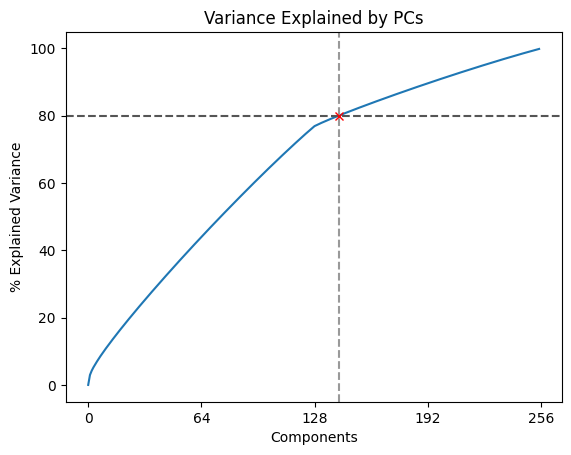

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.plot(np.arange(len(evrs)), [100*np.sum(evrs[:i]) for i in range(len(evrs))])
ax.axhline(p_ev*100, linestyle='--', color='#555555')
ax.axvline(pc_idx, linestyle='--', color='#999999')
ax.plot(pc_idx, p_ev*100, 'x', color='red')
ax.set_xticks(np.arange(0, len(evrs)+1, 64))
ax.set_xlabel("Components"); ax.set_ylabel("% Explained Variance")
ax.set_title(f"Variance Explained by PCs")
plt.show()

### Fit

In [15]:
pca = PCA(pc_idx).fit(X_train)

### Transform

In [16]:
def embed_dset(dataset):
    for session_idx in range(len(dataset)):
        for trial_idx in range(len(dataset[session_idx]['sentenceDat'])):
            dataset[session_idx]['sentenceDat'][trial_idx] = pca.transform(scaler.transform(dataset[session_idx]['sentenceDat'][trial_idx]))

In [17]:
embed_dset(trainDatasets)
embed_dset(testDatasets)
embed_dset(competitionDatasets)

In [18]:
assert np.shape(trainDatasets[0]['sentenceDat'][0])[1] == pc_idx # confirm

## Factor Analysis

### Process Data

In [78]:
from sklearn.preprocessing import StandardScaler

# train
X_train = np.vstack([trainDatasets[session_idx]['sentenceDat'][trial_idx] for session_idx in range(len(trainDatasets)) for trial_idx in range(len(trainDatasets[session_idx]))]) # flatten
scaler = StandardScaler().fit(X_train) # scale
X_train = scaler.transform(X_train)

### Grid Search

In [79]:
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import FactorAnalysis

x_dims = np.arange(0, 256, 16)[1:]
scores = []
for x_dim in x_dims:
    fa = FactorAnalysis(n_components=x_dim)
    cv_scores = cross_val_score(fa, X_train, cv=3, n_jobs=3, verbose=True)
    scores.append(np.mean(cv_scores))

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   14.8s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   25.1s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   55.1s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1.5min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1.5min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1.8min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1

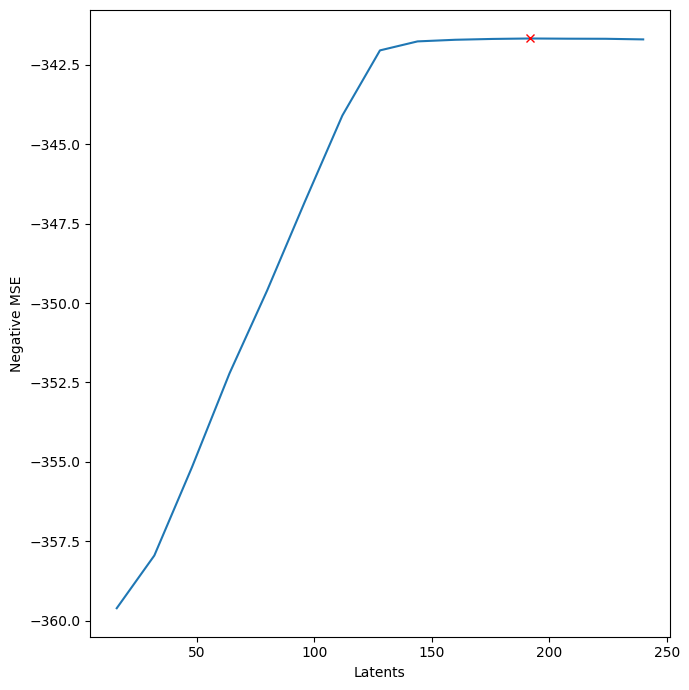

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.xlabel('Latents')
plt.ylabel('Negative MSE')
plt.plot(x_dims, scores)
plt.plot(x_dims[np.argmax(scores)], np.max(scores), 'x', color='r')
plt.tight_layout()
plt.show()

### Fit

In [81]:
num_latents = x_dims[np.argmax(scores)]

# fa = FactorAnalysis(n_components=num_latents).fit(X_train)

In [82]:
num_latents

192

### Transform

In [19]:
def embed_dset(dataset):
    for session_idx in range(len(dataset)):
        for trial_idx in range(len(dataset[session_idx]['sentenceDat'])):
            dataset[session_idx]['sentenceDat'][trial_idx] = fa.transform(scaler.transform(dataset[session_idx]['sentenceDat'][trial_idx]))

In [20]:
embed_dset(trainDatasets)
embed_dset(testDatasets)
embed_dset(competitionDatasets)

In [21]:
assert np.shape(trainDatasets[0]['sentenceDat'][0])[1] == num_latents # confirm

## Autoencoder

### Define AE

In [23]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

class Autoencoder(nn.Module):
    def __init__(self, num_features, num_latents, lr=0.003):
       super(Autoencoder, self).__init__()
       
       self.num_features = num_features
       self.num_latents = num_latents
       self.lr = lr
       self.encoder = nn.Sequential(
           nn.Linear(num_features, 64),
           nn.ReLU(),
           nn.Linear(64, num_latents),
           nn.ReLU()
       )
       
       self.decoder = nn.Sequential(
           nn.Linear(num_latents, 64),
           nn.ReLU(),
           nn.Linear(64, num_features),
           nn.Sigmoid()
       )

    def get_params(self, deep=True):
        return {
            'num_features': self.num_features,
            'num_latents': self.num_latents,
            'lr': self.lr
        }

    def forward(self, X):
       X = self.encoder(X)
       X = self.decoder(X)
       return X

    def fit(self, X, num_epochs=50, verbose=False):
        loss_fn = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), lr=self.lr)

        for epoch in range(num_epochs):
            loss = loss_fn(self(X), X)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if verbose: print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.3f}')
        return self
    
    def score(self, X):
        self.eval()
        loss_fn = nn.MSELoss()

        with torch.no_grad():
            loss = loss_fn(self(X), X)
        
        return -loss.item()

    def transform(self, X):
        encoded_data = self.encoder(X).detach().numpy()
        return encoded_data

/opt/conda/envs/elephant/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Process Data

In [42]:
# train
X_train = np.vstack([trainDatasets[session_idx]['sentenceDat'][trial_idx] for session_idx in range(len(trainDatasets)) for trial_idx in range(len(trainDatasets[session_idx]))]) # flatten
scaler = StandardScaler().fit(X_train) # scale
X_train = torch.FloatTensor(scaler.transform(X_train)) # tensorize

### Grid Search

In [ ]:
from sklearn.model_selection import cross_val_score
num_features = X_train.shape[1]  
x_dims = np.arange(0, 256, 16)[1:]
scores = []
for x_dim in x_dims:
    ae = Autoencoder(num_features, x_dim)
    cv_scores = cross_val_score(ae, X_train, cv=3, n_jobs=3, verbose=True)
    scores.append(np.mean(cv_scores))

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1.0min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   56.2s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   56.0s finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1.1min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1.2min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1.2min finished
[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:  1

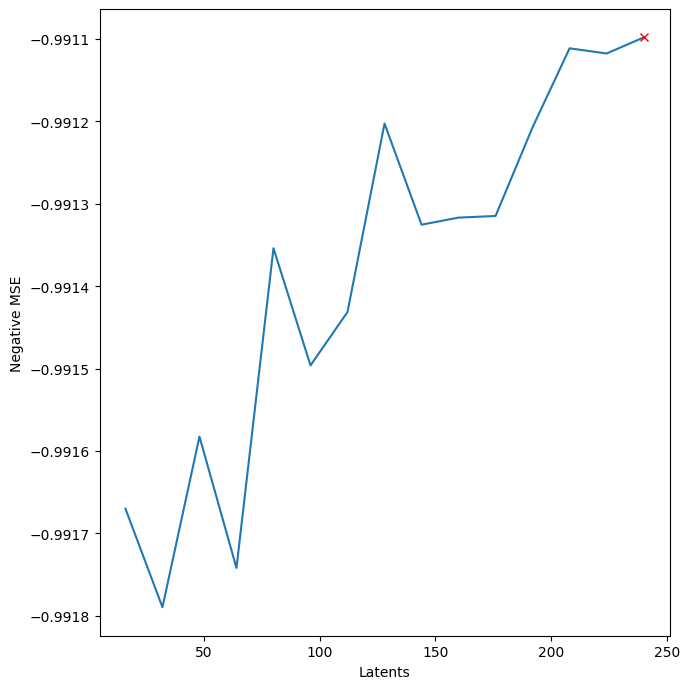

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.xlabel('Latents')
plt.ylabel('Negative MSE')
plt.plot(x_dims, scores, '-')
plt.plot(x_dims[np.argmax(scores)], np.max(scores), 'x', color='r')
plt.tight_layout()
plt.show()

### Fit

In [70]:
num_latents = x_dims[np.argmax(scores[:-1])]

ae = Autoencoder(num_features, num_latents).fit(X_train, num_epochs=50)

In [71]:
num_latents # 16

240

### Transform

In [72]:
def embed_dset(dataset):
    for session_idx in range(len(dataset)):
        for trial_idx in range(len(dataset[session_idx]['sentenceDat'])):
            dataset[session_idx]['sentenceDat'][trial_idx] = ae.transform(torch.FloatTensor(scaler.transform(dataset[session_idx]['sentenceDat'][trial_idx])))

In [73]:
embed_dset(trainDatasets)
embed_dset(testDatasets)
embed_dset(competitionDatasets)

In [74]:
assert np.shape(trainDatasets[0]['sentenceDat'][0])[1] == num_latents # confirm

## GPFA

In [ ]:
from neo.core import SpikeTrain
from quantities import s
from joblib import Parallel, delayed

def train2time(spike_train, trial_duration):
    with open(f"train2time_log.txt", "a") as f:
            print(f"running train2time", file=f)
    vals_unique = np.unique(spike_train)

    spike_times = []
    for i, val in enumerate(vals_unique):
        idxs = np.where(spike_train == val)[0]/50
        spike_times.append(np.repeat(idxs, i))
    
    spike_times = SpikeTrain(spike_times*s, t_stop=trial_duration*s)
    return spike_times

In [ ]:
fs = 50

# (num_trials, num_units, spiketimes)
spike_times = Parallel(n_jobs=-1, backend='loky')(delayed(lambda session_idx, trial_idx: 
                                                          [train2time(trainDatasets[session_idx]['sentenceDat'][trial_idx][:,unit_idx], trial_duration=trainDatasets[session_idx]['timeSeriesLens'][trial_idx]/fs) 
                                                            for unit_idx in range(int(np.shape(trainDatasets[session_idx]['sentenceDat'][trial_idx])[1]/2))])(session_idx, trial_idx) 
                                                            for session_idx in range(len(trainDatasets)) for trial_idx in range(len(trainDatasets[session_idx]['sentenceDat']))) 

In [ ]:
from sklearn.model_selection import cross_val_score
from elephant.gpfa import GPFA

x_dims = np.arange(1,5)
log_likelihoods = []
for x_dim in x_dims:
    gpfa_cv = GPFA(x_dim=x_dim, verbose=True)
    cv_log_likelihoods = cross_val_score(gpfa_cv, spike_times, cv=3, n_jobs=3, verbose=True)
    log_likelihoods.append(np.mean(cv_log_likelihoods))

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
/opt/conda/envs/elephant/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

f = plt.figure(figsize=(7, 5))
plt.xlabel('Latents')
plt.ylabel('Log-likelihood')
plt.plot(x_dims, log_likelihoods, '.-')
plt.plot(x_dims[np.argmax(log_likelihoods)], np.max(log_likelihoods), 'x', markersize=10, color='r')
plt.tight_layout()
plt.show()

# Save Data

In [75]:
import pickle

allDatasets = {}
allDatasets['train'] = trainDatasets
allDatasets['test'] = testDatasets
allDatasets['competition'] = competitionDatasets

with open('../competitionData/ptDecoder_ctc', 'wb') as handle:
    pickle.dump(allDatasets, handle)

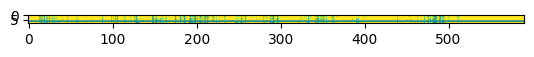

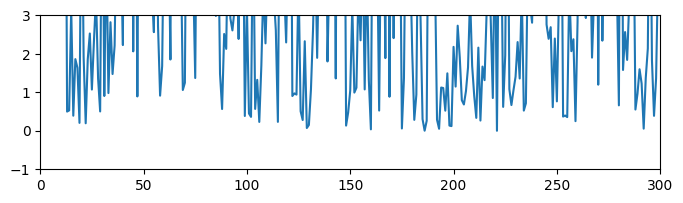

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(trainDatasets[0]['sentenceDat'][10].T, clim=[-1,1])
plt.show()

plt.figure(figsize=(8,2)) 
plt.plot(trainDatasets[0]['sentenceDat'][10][:,0])
# plt.plot(trainDatasets[0]['sentenceDat'][10][:,128])
plt.xlim([0,300])
plt.ylim([-1,3])
plt.show()